# Setup

In [13]:
!pip install mujoco
!pip install gymnasium
!pip install matplotlib
!pip install imageio
!pip install numpy
!pip install opencv-python
!pip install h5py
!pip install tqdm

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os

os.chdir("/content/drive/MyDrive/visual-policy-learning")
os.environ["MUJOCO_GL"] = "egl"


In [16]:
import importlib

import envs.panda_reach_env
import policies.scripted_policy
import data.collect_demos

importlib.reload(envs.panda_reach_env)
importlib.reload(policies.scripted_policy)
importlib.reload(data.collect_demos)

from envs.panda_reach_env import PandaReachEnv
from policies.scripted_policy import ScriptedPolicy

from data.collect_demos import collect_demos, save_hdf5, load_hdf5, verify_dataset

# Data Generation

In [17]:
env = PandaReachEnv(
    render_mode=False,
    image_width=64,
    image_height=64,
    max_steps=300,
    physics_steps=4,
)

policy = ScriptedPolicy(env.model, env.data)

dataset = collect_demos(
    env,
    policy,
    num_episodes=100,
    seed=42,
)


[EP 0] steps=33 success=True dist=0.033
[EP 1] steps=36 success=True dist=0.048
[EP 2] steps=80 success=True dist=0.045
[EP 3] steps=32 success=True dist=0.022
[EP 4] steps=37 success=True dist=0.021
[EP 5] steps=78 success=True dist=0.041
[EP 6] steps=35 success=True dist=0.047
[EP 7] steps=77 success=True dist=0.040
[EP 8] steps=37 success=True dist=0.044
[EP 9] steps=39 success=True dist=0.031
[EP 10] steps=37 success=True dist=0.036
[EP 11] steps=33 success=True dist=0.025
[EP 12] steps=34 success=True dist=0.044
[EP 13] steps=35 success=True dist=0.032
[EP 14] steps=41 success=True dist=0.048
[EP 15] steps=35 success=True dist=0.028
[EP 16] steps=32 success=True dist=0.026
[EP 17] steps=32 success=True dist=0.030
[EP 18] steps=36 success=True dist=0.045
[EP 19] steps=37 success=True dist=0.047
[EP 20] steps=34 success=True dist=0.044
[EP 21] steps=37 success=True dist=0.050
[EP 22] steps=41 success=True dist=0.048
[EP 23] steps=36 success=True dist=0.049
[EP 24] steps=83 success=T

In [18]:
save_hdf5(
    dataset,
    "data/panda_demos.h5"
)

Saved HDF5 dataset to: data/panda_demos.h5


# Verification

In [19]:
data = load_hdf5("data/panda_demos.h5")

verify_dataset(data)


========== DATASET CHECK ==========
actions: shape=(4623, 8), dtype=float32
dones: shape=(4623,), dtype=bool
episode_ends: shape=(100,), dtype=int32
observations: shape=(4623, 64, 64, 3), dtype=uint8
rewards: shape=(4623,), dtype=float32
states: shape=(4623, 9), dtype=float32
success: shape=(4623,), dtype=bool
targets: shape=(4623, 3), dtype=float32

Sample checks:

Step 0
action: [ 0.5     0.5     0.5    -0.0698  0.5    -0.0175  0.      0.    ]
state: [0. 0. 0. 0. 0.] ...
reward: -0.70121866
done: False
success: False

Step 1
action: [ 0.5107001   0.49916533  0.51453626 -0.0698      0.4964583  -0.0175
 -0.00456804  0.        ]
state: [ 0.01070013 -0.00083467  0.01453623 -0.0052022  -0.0035417 ] ...
reward: -0.7316387
done: False
success: False

Step 2
action: [ 0.53881454  0.50004864  0.549578   -0.0698      0.48754343 -0.0175
 -0.01717008  0.        ]
state: [ 3.8814526e-02  4.8641534e-05  4.9578022e-02 -1.2169512e-02
 -1.2456562e-02] ...
reward: -0.72760165
done: False
success: Fal

In [20]:
import h5py
import numpy as np

# With render_mode=False during collection, observations are zero placeholders.
# Real RGB frames are produced in training.ipynb (rendering cell).

with h5py.File("data/panda_demos.h5", "r") as f:
    states = f["states"][:]
    actions = f["actions"][:]
    targets = f["targets"][:] if "targets" in f else None

    print("states:", states.shape, states.dtype)
    print("actions:", actions.shape, actions.dtype)
    if targets is not None:
        print("targets:", targets.shape, targets.dtype)
        print("target sample:", targets[0])

    print("\nstate min/max:", states.min(), states.max())
    print("action min/max:", actions.min(), actions.max())


states: (4623, 9) float32
actions: (4623, 8) float32
targets: (4623, 3) float32
target sample: [0.506181  0.1352143 0.4463988]

state min/max: -1.8849669 1.0933362
action min/max: -2.1574142 1.2732764


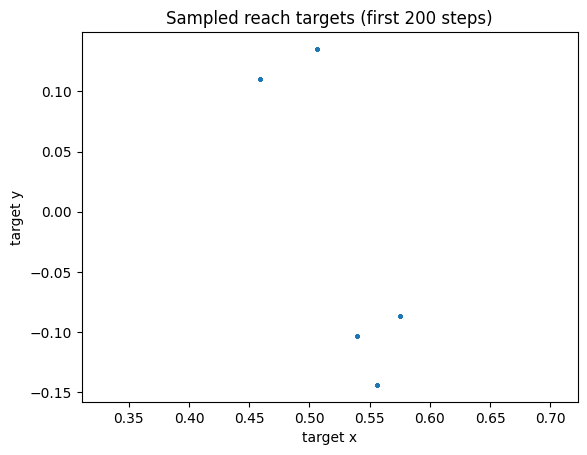

In [21]:
import matplotlib.pyplot as plt
import h5py

# Plot target positions (observations are zeros until rendering step)
with h5py.File("data/panda_demos.h5", "r") as f:
    targets = f["targets"][:200]

plt.scatter(targets[:, 0], targets[:, 1], s=4, alpha=0.6)
plt.xlabel("target x")
plt.ylabel("target y")
plt.title("Sampled reach targets (first 200 steps)")
plt.axis("equal")
plt.show()
